# Anticipacion de Fallas en un Reactor Quimico
## Clasificacion supervisada de eventos de falla con DNN / LSTM / GRU

El modelo predice **si el sistema estara en falla** en los proximos minutos. Es un problema de **clasificacion binaria** que usa las etiquetas `fault_type` del dataset.


**Diseno de evaluacion (hold-out por reactor):** se entrena con 4 reactores, se valida en uno y se **testea en un reactor no visto (`B_R3`)**, para medir generalizacion real.

## 1. Librerias

In [ ]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, roc_curve, classification_report, accuracy_score
SEED=42; np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Carga y tratamiento de datos
Carga de datos y tratamiento de datos nulos (interpolacion temporal + ffill/bfill, por reactor).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/My Drive/Tp Final/chemical_process_timeseries.csv")

feat = ['ambient_temp_effect','reactor_temp','reactor_pressure','feed_flow_rate','coolant_flow_rate',
        'agitator_speed_rpm','reaction_rate','conversion_rate','selectivity','yield_pct',
        'vibration_rms','motor_current','power_consumption_kw','temp_setpoint','pressure_setpoint']
pc = feat + ['efficiency_loss_pct']

def tratar_nulos(g):
    g['timestamp'] = pd.to_datetime(g['timestamp'])
    g = g.sort_values('timestamp').set_index('timestamp')
    g[pc] = g[pc].interpolate(method='time', limit_direction='both').ffill().bfill()
    return g.reset_index()

df = df.groupby('reactor_id', group_keys=False)[df.columns].apply(tratar_nulos)
print("Nulos en features:", int(df[feat].isna().sum().sum()))

Mounted at /content/drive
Nulos en features: 0


## 3. Etiqueta de falla y split por reactor

La **etiqueta** es binaria: `1` = el sistema esta en falla (`fault_type != 0`), `0` = normal.

In [ ]:
TR = ['A_R1','A_R2','B_R1','B_R2']     # entrenamiento
VA = ['A_R3']                          # validacion
TE = ['B_R3']                          # test (reactor NO visto)

df['label'] = (df['fault_type'].values != 0).astype('float32')
for nombre, rids in [("train",TR),("val",VA),("test",TE)]:
    g = df[df.reactor_id.isin(rids)]
    print(f"{nombre:5s} {rids} -> n={len(g)}  %falla={100*g['label'].mean():.2f}")

train ['A_R1', 'A_R2', 'B_R1', 'B_R2'] -> n=518400  %falla=3.39
val   ['A_R3'] -> n=129600  %falla=3.61
test  ['B_R3'] -> n=129600  %falla=4.36


### 3.1 Estandarizacion (solo con reactores de TRAIN)
Las setpoints son constantes (desvio 0): se fija a 1 para no generar `NaN`.

In [ ]:
train_mask = df.reactor_id.isin(TR).values
mean = df.loc[train_mask, feat].values.mean(0)
std  = df.loc[train_mask, feat].values.std(0)
std[std == 0] = 1.0
df[feat] = (df[feat].values - mean) / std

## 4. Ventanas temporales

Misma maquinaria que en forecasting (`timeseries_dataset_from_array`) pero con `targets = label`. Usamos `sequence_stride` para reducir la cantidad de ventanas (el dataset es grande). Las ventanas no cruzan el limite entre reactores.

In [ ]:
# --- Hiperparámetros de ventana ---
SEQ    = 40   # pasos de historia por ventana (= 60 minutos)
H      = 10   # horizonte de predicción (= 30 minutos hacia adelante)
STRIDE = 6    # desplazamiento entre ventanas consecutivas (1 ventana cada 6 min)
BS     = 256  # tamaño de batch

delay = SEQ + H - 1




def make_ds(reactor_ids, shuffle): #Funcion para crear dataset ventana para entrenar
    dataset = None

    for reactor in reactor_ids:
        # Datos del reactor ordenados cronológicamente
        grupo = df[df.reactor_id == reactor].sort_values('timestamp')
        x = grupo[feat].values.astype('float32')
        y = grupo['label'].values.astype('float32')

        # Cada ventana: x[i : i+SEQ]  →  y[i + delay]
        ds_reactor = keras.utils.timeseries_dataset_from_array(
            data=x[:-delay],
            targets=y[delay:],
            sequence_length=SEQ,
            sequence_stride=STRIDE,
            batch_size=BS,
            shuffle=False,
        )

        dataset = ds_reactor if dataset is None else dataset.concatenate(ds_reactor) # Agrupo los Dataset

    if shuffle:
        dataset = dataset.shuffle(buffer_size=20_000, seed=SEED) #Mezclo las ventanas de los reactores

    return dataset


# Construcción de los tres splits
train_ds = make_ds(TR, shuffle=True)
val_ds   = make_ds(VA, shuffle=False)
test_ds  = make_ds(TE, shuffle=False)

# Verificación rápida de shapes
for x_batch, y_batch in train_ds:
    print(f"Shape de entrada : {x_batch.shape}  ->  (batch, pasos, features)")
    print(f"Shape de salida  : {y_batch.shape}   ->  (batch,)")
    break


Shape de entrada : (256, 40, 15)  ->  (batch, pasos, features)
Shape de salida  : (256,)   ->  (batch,)


### 4.1 Pesos de clase (desbalance)
Con ~3-4 % de positivos, hay que ponderar mas la clase falla para que el modelo no la ignore.

In [ ]:
p = df.loc[train_mask, 'label'].mean() #Calculo la media de falla de los reactores de media (aprx 3%)
class_weight = {0: 1.0, 1: float((1 - p) / p)/4} #Si no es falla peso 1. Si es falla el peso la frecuencia que ocurre la falla
print("class_weight:", {k: round(v,1) for k,v in class_weight.items()})

class_weight: {0: 1.0, 1: 7.1}


## 5. Modelos (salida sigmoide)

La ultima capa es `Dense(1, activation='sigmoid')` y la perdida `binary_crossentropy`. Las metricas son AUC, recall y precision (no MAE, no accuracy).

In [ ]:
def build(kind):
    inp = keras.Input(shape=(SEQ, len(feat)), name="entrada")
    if kind == "DNN":
        x = layers.Dense(12, activation="relu")(layers.Flatten()(inp))
    elif kind == "LSTM":
        x = layers.LSTM(12)(inp)
    else:  # GRU
        x = layers.Dropout(0.3)(layers.GRU(12)(inp))
    out = layers.Dense(1, activation="sigmoid", name="salida")(x)
    m = keras.Model(inp, out, name=f"clf_{kind}")
    m.compile(optimizer="adam", loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="auc"),
                       keras.metrics.Recall(name="rec"),
                       keras.metrics.Precision(name="prec")])
    return m

EPOCHS = 5
def entrenar(kind):
    m = build(kind)
    h = m.fit(train_ds, epochs=EPOCHS, validation_data=val_ds,
              class_weight=class_weight, verbose=2)
    print(f"[{kind}] val AUC final: {h.history['val_auc'][-1]:.3f}")
    return m, h

### 5.1 Entrenamiento

In [ ]:
model_dnn,  h_dnn  = entrenar("DNN")
model_lstm, h_lstm = entrenar("LSTM")
model_gru,  h_gru  = entrenar("GRU")

Epoch 1/5
340/340 - 18s - 54ms/step - auc: 0.7109 - loss: 0.5667 - prec: 0.2076 - rec: 0.4294 - val_auc: 0.9220 - val_loss: 0.1599 - val_prec: 0.9431 - val_rec: 0.6167
Epoch 2/5
340/340 - 17s - 51ms/step - auc: 0.9149 - loss: 0.2858 - prec: 0.5752 - rec: 0.6816 - val_auc: 0.8714 - val_loss: 0.0893 - val_prec: 0.9409 - val_rec: 0.5103
Epoch 3/5
340/340 - 18s - 54ms/step - auc: 0.8976 - loss: 0.2912 - prec: 0.7571 - rec: 0.6713 - val_auc: 0.9530 - val_loss: 0.1251 - val_prec: 0.9492 - val_rec: 0.6462
Epoch 4/5
340/340 - 17s - 51ms/step - auc: 0.9321 - loss: 0.2493 - prec: 0.5599 - rec: 0.7502 - val_auc: 0.9345 - val_loss: 0.0877 - val_prec: 0.9471 - val_rec: 0.6654
Epoch 5/5
340/340 - 17s - 50ms/step - auc: 0.9440 - loss: 0.2336 - prec: 0.8561 - rec: 0.7249 - val_auc: 0.8645 - val_loss: 0.0838 - val_prec: 0.9480 - val_rec: 0.5846
[DNN] val AUC final: 0.865
Epoch 1/5
340/340 - 27s - 78ms/step - auc: 0.5714 - loss: 0.6413 - prec: 0.0371 - rec: 0.0648 - val_auc: 0.7520 - val_loss: 0.2875 - 

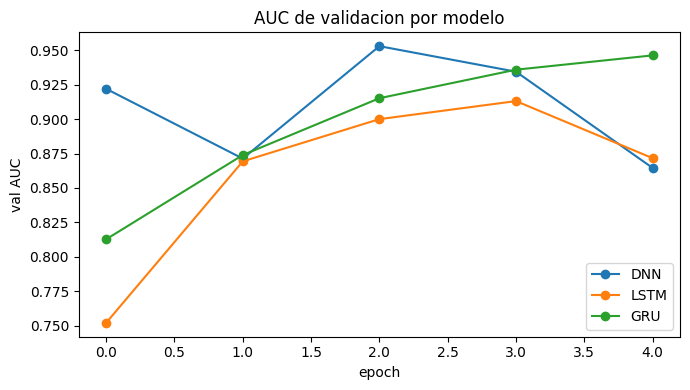

In [ ]:
plt.figure(figsize=(7,4))
for h,n in [(h_dnn,"DNN"),(h_lstm,"LSTM"),(h_gru,"GRU")]:
    plt.plot(h.history["val_auc"], marker="o", label=n)
plt.xlabel("epoch"); plt.ylabel("val AUC"); plt.title("AUC de validacion por modelo")
plt.legend(); plt.tight_layout(); plt.show()

## 6. Evaluacion en el reactor no visto (B_R3)

El mejor modelo (GRU) se evalua sobre `B_R3`, que el modelo nunca vio en entrenamiento.

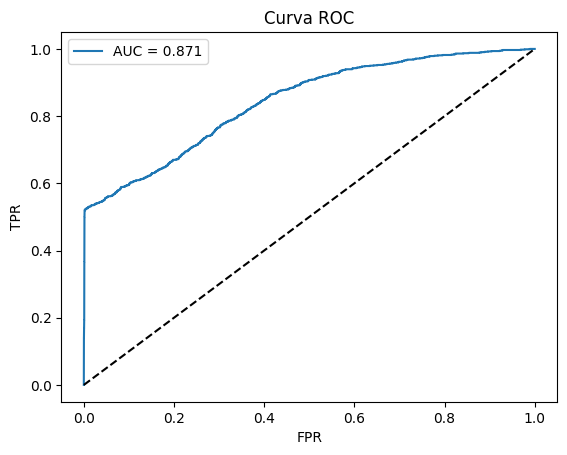

In [ ]:
mejor = model_gru
y_true, y_prob = [], []
y_prob = mejor.predict(test_ds, verbose=0).ravel()
y_true = np.concatenate([yb.numpy() for _, yb in test_ds])


plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true, y_prob):.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("Curva ROC")
plt.legend()
plt.show()


In [ ]:
mejor = model_gru
y_true, y_prob = [], []
for xb, yb in test_ds:
    y_prob += list(mejor.predict(xb, verbose=0).ravel()); y_true += list(yb.numpy())
y_true, y_prob = np.array(y_true), np.array(y_prob)

# Convert probabilities to binary predictions using the defined threshold
y_pred = (y_prob > 0.5).astype(int)

report=classification_report(y_true, y_pred, target_names=["Normal","Falla"], digits=3)
print(report)

              precision    recall  f1-score   support

      Normal      0.978     0.999     0.988     20645
       Falla      0.977     0.499     0.661       941

    accuracy                          0.978     21586
   macro avg      0.977     0.749     0.825     21586
weighted avg      0.978     0.978     0.974     21586



### 6.1 Eleccion del umbral

El umbral 0.5 maximiza recall pero genera muchas falsas alarmas. Subirlo mejora la precision. Barremos varios umbrales para elegir el punto de operacion.

In [ ]:
for thr in [0.5,0.7,0.9,0.95,0.99]:
    yh = (y_prob > thr).astype(int)
    tp=((yh==1)&(y_true==1)).sum(); fp=((yh==1)&(y_true==0)).sum(); fn=((yh==0)&(y_true==1)).sum()
    print(f"thr={thr:>4}: TP={rec:.3f}  precision={prec:.3f}  F1={f1:.3f}  (FP={fp})  (FN={fn})")
    report=classification_report(y_true, yh, target_names=["Normal","Falla"], digits=3)
    print(report)


thr= 0.5: TP=0.000  precision=0.000  F1=0.000  (FP=11)  (FN=471)
              precision    recall  f1-score   support

      Normal      0.978     0.999     0.988     20645
       Falla      0.977     0.499     0.661       941

    accuracy                          0.978     21586
   macro avg      0.977     0.749     0.825     21586
weighted avg      0.978     0.978     0.974     21586

thr= 0.7: TP=0.000  precision=0.000  F1=0.000  (FP=10)  (FN=501)
              precision    recall  f1-score   support

      Normal      0.976     1.000     0.988     20645
       Falla      0.978     0.468     0.633       941

    accuracy                          0.976     21586
   macro avg      0.977     0.734     0.810     21586
weighted avg      0.976     0.976     0.972     21586

thr= 0.9: TP=0.000  precision=0.000  F1=0.000  (FP=8)  (FN=562)
              precision    recall  f1-score   support

      Normal      0.973     1.000     0.986     20645
       Falla      0.979     0.403     0.571

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


B_R3: 1 eventos (tipo=1)
  [0] inicio min 50361 (2024-02-04 23:21:00), duración 599 min


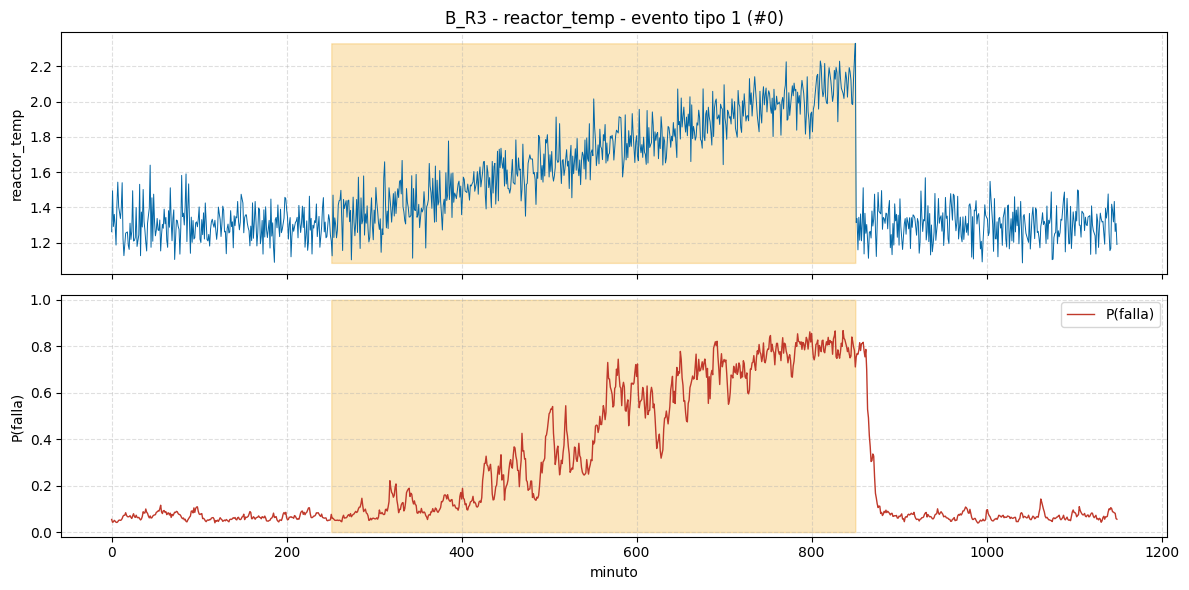

In [ ]:
# --- Elegí qué evento mostrar ---
REACTOR_PLOT = "B_R3"     # cualquier reactor
TIPO_FALLA   = 1          # 1=enfriamiento, 2=bloqueo, 3=sensor drift, 4=desgaste, None=cualquiera
EVENTO_NUM   = 0          # 0 = primero, 1 = segundo, ...

VAR_PLOT = None
var_por_falla = {1:"reactor_temp", 2:"feed_flow_rate", 3:"feed_flow_rate", 4:"agitator_speed_rpm"}
var_top = VAR_PLOT or var_por_falla.get(TIPO_FALLA, "reactor_temp")

g  = df[df.reactor_id==REACTOR_PLOT].sort_values("timestamp").reset_index(drop=True)
ft = g['fault_type'].values
X  = g[feat].values.astype('float32')
mask = (ft != 0) if TIPO_FALLA is None else (ft == TIPO_FALLA)
starts = np.where(mask & ~np.r_[False, mask[:-1]])[0]
ends   = np.where(mask & ~np.r_[mask[1:], False])[0]

print(f"{REACTOR_PLOT}: {len(starts)} eventos (tipo={TIPO_FALLA})")
for i,(s,e) in enumerate(zip(starts,ends)):
    print(f"  [{i}] inicio min {s} ({g.timestamp[s]}), duración {e-s} min")

c   = starts[EVENTO_NUM]
dur = ends[EVENTO_NUM] - c
lo  = max(0, c-300); hi = min(len(g), c + dur + 300)

idx   = np.arange(lo, hi-delay)
wins  = np.stack([X[i:i+SEQ] for i in idx])
prob  = model_gru.predict(wins, verbose=0).ravel()
realf = (ft[idx+delay]!=0).astype(int); tt = np.arange(len(idx))

fig,ax = plt.subplots(2,1,figsize=(12,6),sharex=True)
temp = g['reactor_temp'].values[idx+delay]
serie_top = g[var_top].values[idx+delay]
ax[0].plot(tt, serie_top, color="#0367A6", lw=0.7)
ax[0].fill_between(tt, serie_top.min(), serie_top.max(), where=realf==1, color="#F2A104", alpha=0.25, label="falla real")
ax[0].set_ylabel(var_top)
ax[0].set_title(f"{REACTOR_PLOT} - {var_top} - evento tipo {TIPO_FALLA} (#{EVENTO_NUM})")
ax[1].plot(tt, prob, color="#C0392B", lw=1, label="P(falla)")
ax[1].fill_between(tt, 0, 1, where=realf==1, color="#F2A104", alpha=0.25)
ax[1].set_ylim(-0.02,1.02); ax[1].set_ylabel("P(falla)"); ax[1].set_xlabel("minuto"); ax[1].legend()
ax[0].grid(True, linestyle="--", alpha=0.4)
ax[1].grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

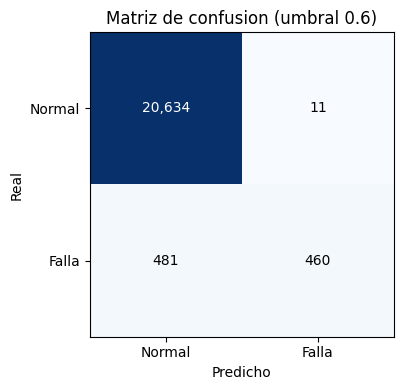

In [ ]:
THR = 0.6            # punto de operacion elegido
y_pred = (y_prob > THR).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4.2,4)); plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j,i,f"{cm[i,j]:,}",ha="center",va="center",
                 color="white" if cm[i,j]>cm.max()/2 else "black")
plt.xticks([0,1],["Normal","Falla"]); plt.yticks([0,1],["Normal","Falla"])
plt.xlabel("Predicho"); plt.ylabel("Real"); plt.title(f"Matriz de confusion (umbral {THR})")
plt.tight_layout(); plt.show()

## 7. Linea temporal: probabilidad de falla vs. evento real

Se grafica la probabilidad predicha alrededor de un evento en `B_R3`. La probabilidad debe subir en la fase temprana de la falla.

B_R3: 3 eventos (tipo=2)
  [0] inicio min 72595 (2024-02-20 09:55:00), duración 203 min
  [1] inicio min 94036 (2024-03-06 07:16:00), duración 1098 min
  [2] inicio min 126964 (2024-03-29 04:04:00), duración 653 min


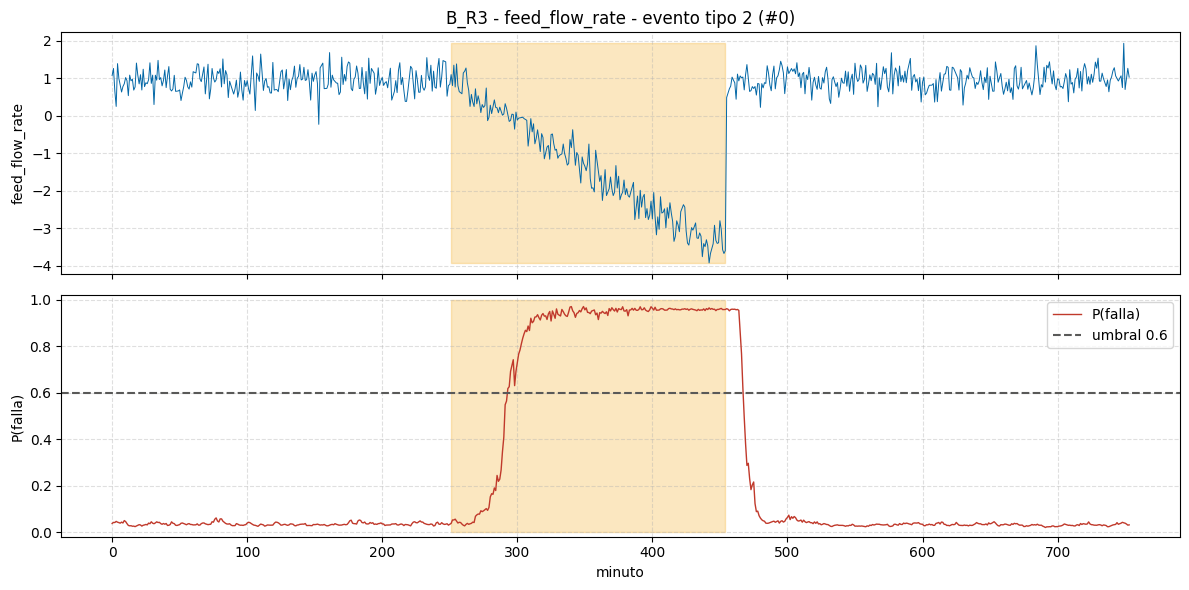

In [ ]:
# --- Elegí qué evento mostrar ---
REACTOR_PLOT = "B_R3"     # cualquier reactor
TIPO_FALLA   = 2          # 1=enfriamiento, 2=bloqueo, 3=sensor drift, 4=desgaste, None=cualquiera
EVENTO_NUM   = 0         # 0 = primero, 1 = segundo, ...

VAR_PLOT = None
var_por_falla = {1:"reactor_temp", 2:"feed_flow_rate", 3:"feed_flow_rate", 4:"agitator_speed_rpm"}
var_top = VAR_PLOT or var_por_falla.get(TIPO_FALLA, "reactor_temp")

g  = df[df.reactor_id==REACTOR_PLOT].sort_values("timestamp").reset_index(drop=True)
ft = g['fault_type'].values
X  = g[feat].values.astype('float32')
mask = (ft != 0) if TIPO_FALLA is None else (ft == TIPO_FALLA)
starts = np.where(mask & ~np.r_[False, mask[:-1]])[0]
ends   = np.where(mask & ~np.r_[mask[1:], False])[0]

print(f"{REACTOR_PLOT}: {len(starts)} eventos (tipo={TIPO_FALLA})")
for i,(s,e) in enumerate(zip(starts,ends)):
    print(f"  [{i}] inicio min {s} ({g.timestamp[s]}), duración {e-s} min")

c   = starts[EVENTO_NUM]
dur = ends[EVENTO_NUM] - c
lo  = max(0, c-300); hi = min(len(g), c + dur + 300)

idx   = np.arange(lo, hi-delay)
wins  = np.stack([X[i:i+SEQ] for i in idx])
prob  = model_gru.predict(wins, verbose=0).ravel()
realf = (ft[idx+delay]!=0).astype(int); tt = np.arange(len(idx))

fig,ax = plt.subplots(2,1,figsize=(12,6),sharex=True)
temp = g['reactor_temp'].values[idx+delay]
serie_top = g[var_top].values[idx+delay]
ax[0].plot(tt, serie_top, color="#0367A6", lw=0.7)
ax[0].fill_between(tt, serie_top.min(), serie_top.max(), where=realf==1, color="#F2A104", alpha=0.25, label="falla real")
ax[0].set_ylabel(var_top)
ax[0].set_title(f"{REACTOR_PLOT} - {var_top} - evento tipo {TIPO_FALLA} (#{EVENTO_NUM})")
ax[1].plot(tt, prob, color="#C0392B", lw=1, label="P(falla)")
ax[1].axhline(THR, ls="--", color="#595958", label=f"umbral {THR}")
ax[1].fill_between(tt, 0, 1, where=realf==1, color="#F2A104", alpha=0.25)
ax[1].set_ylim(-0.02,1.02); ax[1].set_ylabel("P(falla)"); ax[1].set_xlabel("minuto"); ax[1].legend()
ax[0].grid(True, linestyle="--", alpha=0.4)
ax[1].grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()
